In [16]:
import sklearn
print(sklearn.__version__)

import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Other plots (example)

from src.exp import (
    FeatureSchema, ExperimentConfig, ExperimentFacade,
    DataReadConfig, PlotManager
)

1.8.0


In [17]:
try:
    from sklearnex import patch_sklearn
    patch_sklearn()
    print("Intel sklearn patch enabled")
except ImportError:
    print("sklearnex not installed; using standard sklearn")


sklearnex not installed; using standard sklearn


In [18]:
schema = FeatureSchema(
    target="price",
    num_cols=["year","engineSize","mpg","tax","mileage"],
    cat_cols=["model","fuelType","transmission"]
)


In [19]:
cfg = ExperimentConfig(outer_folds=5, inner_folds=5, n_trials=40, seed=42, log_target=True)

In [20]:
data_cfg = DataReadConfig(
    root_dir="Dataset/data",
    recursive=True,
    exclude_filenames=["cclass.csv", "unclean focus.csv","unclean cclass.csv","focus.csv"],  # the excluded files
    add_source_column=True,
    encoding="utf-8",
)

In [21]:
models = ["XGBoost"]#["LinearRegression","DecisionTree","RandomForest","SVR", "XGBoost","NeuralNetwork"]

In [22]:
exp = ExperimentFacade.from_folder(
    data_cfg=data_cfg,
    schema=schema,
    cfg=cfg,
    model_names=models,
    hparam_json="config/hyperparams.json"
)

In [ ]:
results = exp.run()

[I 2026-01-24 08:12:59,375] A new study created in memory with name: XGBoost_OuterFold_1
[I 2026-01-24 08:13:41,366] Trial 0 finished with value: 0.9025539694375391 and parameters: {'n_estimators': 1424, 'max_depth': 7, 'min_child_weight': 9, 'learning_rate': 0.027108149445856267, 'subsample': 0.6923529515220681, 'colsample_bytree': 0.6369946531259763, 'gamma': 3.3398120470403665, 'reg_alpha': 0.0005865770613435768, 'reg_lambda': 0.004024162196859075, 'early_stopping_rounds': 245}. Best is trial 0 with value: 0.9025539694375391.
[I 2026-01-24 08:15:15,227] Trial 1 finished with value: 0.9429655321272508 and parameters: {'n_estimators': 3396, 'max_depth': 2, 'min_child_weight': 6, 'learning_rate': 0.1823727072591649, 'subsample': 0.7337994503617092, 'colsample_bytree': 0.570085703825056, 'gamma': 0.2103428979508054, 'reg_alpha': 0.1247308512047032, 'reg_lambda': 0.3223423233794295, 'early_stopping_rounds': 276}. Best is trial 1 with value: 0.9429655321272508.
[I 2026-01-24 08:17:18,118]

In [ ]:
display(exp.summary())


,model,R2_mean,R2_std,MAE_mean,MAE_std,MedAE_mean,MedAE_std,MSE_mean,MSE_std,RMSE_mean,RMSE_std
0,LinearRegression,-2.606856,7.77118,2110.81004,122.029471,1332.976244,7.017524,3.529705e+08,7.606829e+08,11138.970659,16915.000996


In [ ]:
sig = exp.significance(metric="R2", baseline="LinearRegression")
display(sig)

,metric,baseline,model,paired_t_p,wilcoxon_p,n_outer_folds


[saved] /Users/macbook/Library/CloudStorage/GoogleDrive-nur.ichsan@gmail.com/My Drive/UNS/2023/Business Intelligence/Paper/Salomo/NewIJAI/outputs/figures/shap/shap_beeswarm_linearregression.png


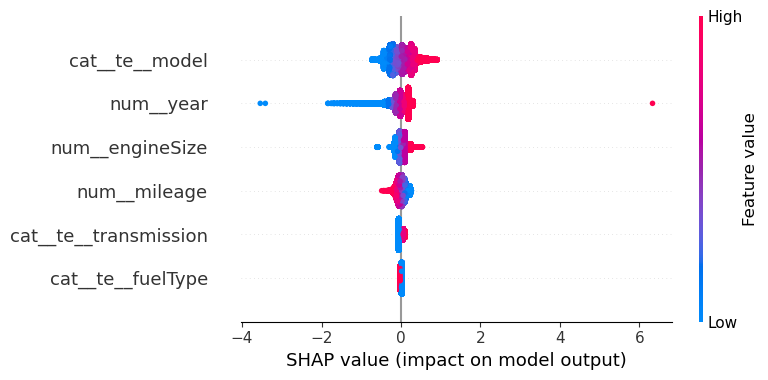

In [ ]:
sh = exp.shap(plot_dir="outputs/figures/shap")
sh.beeswarm("LinearRegression", max_display=15)

In [ ]:
def plot_model_comparison(df_summary, plot_manager=None):

    df_summary.set_index("model")["MAE_mean"].plot(kind="bar")
    plt.ylabel("R2")

    if plot_manager is not None:
        plot_manager.save("model_comparison_mae")

    plt.show()


[saved] /Users/macbook/Library/CloudStorage/GoogleDrive-nur.ichsan@gmail.com/My Drive/UNS/2023/Business Intelligence/Paper/Salomo/NewIJAI/outputs/figures/metrics/model_comparison_mae.png


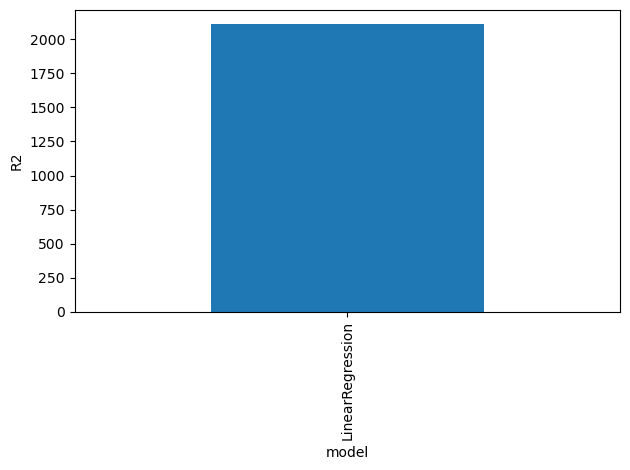

In [ ]:

pm = PlotManager("outputs/figures/metrics")
plot_model_comparison(exp.summary(), plot_manager=pm)

In [ ]:
significance_matrix = exp.significance_matrix(metric="R2")
display(significance_matrix)

,metric,model_a,model_b,paired_t_p,wilcoxon_p,n_outer_folds


In [ ]:
exp.save_best_params()

[saved] /Users/macbook/Library/CloudStorage/GoogleDrive-nur.ichsan@gmail.com/My Drive/UNS/2023/Business Intelligence/Paper/Salomo/NewIJAI/outputs/best_params/best_params.json
